<a href="https://colab.research.google.com/github/anferivera/Fisica_Computacional_1/blob/main/2_finite_differece_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

## 2. Diffusion equation by FDM

\begin{equation}
\boxed{
\nabla^2 u(x,y,t)= \dfrac{\partial^2 u(x,y,t)}{\partial x^2} +\dfrac{\partial^2 u(x,y,t)}{\partial y^2}= \dfrac{1}{\alpha}\dfrac{\partial u(x,y,t)}{\partial t}}\,,
\end{equation}

where $1/\alpha$ is the diffusion coefficient. Here, we will express derivatives in terms of finite differences in the values of $u$ at the laticce sites. For space coordinates in 2D:


\begin{align}
\dfrac{\partial^2 u(x,y)}{\partial x^2}+\dfrac{\partial^2 u(x,y)}{\partial y^2} &\approx \dfrac{u(x+\Delta x,y)+u(x-\Delta x,y)-2u(x,y)}{(\Delta x)^2}\nonumber\\ & +  \dfrac{u(x, y+\Delta y)+u(x,y-\Delta y)-2u(x,y)}{(\Delta y)^2} \,.
\end{align}

For time:
* Derivate to the right:
\begin{align}
u(x,y,t+\Delta t) = u(x,y,t) + \dfrac{\partial u}{\partial t}\Delta t + \dfrac{1\partial^2 u}{2\partial t^2}(\Delta t)^2 + \cdots
\end{align}
* Derivate to the left:
\begin{align}
u(x,y,t-\Delta t) = u(x,y,t) - \dfrac{\partial u}{\partial t}\Delta t + \dfrac{1\partial^2 u}{2\partial t^2}(\Delta t)^2 + \cdots\,,
\end{align}
* Central derivative:
\begin{align}
\dfrac{\partial u}{\partial t} \approx \dfrac{u(x,y,t+\Delta t) -u(x,y,t-\Delta t)}{2\Delta t} \,.
\end{align}

Let's suppose $\Delta x=\Delta y$, $x_i=x_0+i\Delta$, $y_j=y_0+j\Delta$, $t_k=k\Delta t$, $\{i,j,k\}=0,\cdots N$. Using the derivative to the right (forward in time), the Diffusion's equation can be writeen as:

\begin{align}
\dfrac{\big[ u_{i+1,j,k}+u_{i-i,j,k} +
u_{i,j+1,k}+u_{i,j-1,k} -4u_{i,j,k} \big]}{\Delta^2}
= \dfrac{1}{\alpha}\dfrac{\big(u_{i,j,k+1}-u_{i,j,k}\big)}{\Delta t}\,,
\end{align}
and the state of the system at time step $k+1$ may be calculated from its state at time step $k$ as:

\begin{align}
\boxed{
u_{i,j,k+1}=u_{i,j,k}+\alpha\Delta t\,\dfrac{\big[ u_{i+1,j,k}+u_{i-i,j,k} +
u_{i,j+1,k}+u_{i,j-1,k} -4u_{i,j,k} \big]}{\Delta^2}} \,.
\end{align}



### Example 1: Heat diffusion in a plate

Consider the diffusion equation applied to a metal plate initially at temperature $T_\text{cold}$  apart from a disc of a specified size which is at temperature $T_\text{hot}$. We suppose that the edges of the plate are held fixed at $T_\text{cold}$. The following code applies the above formula to follow the evolution of the temperature of the plate.

<img src="figures/plato_coductor1.jpg" alt="Texto alternativo" width="400" height="400">

In the code below, each call to `do_timestep` updates the numpy array $u$ from the results of the previous timestep $u_0$. It does not apply directly the algorithm because this runs extremely slow and using vectorization will farm out these explicit loops to the much faster pre-compiled C-code underlying NumPy's array implementation.

Taken from: https://scipython.com/books/book2/chapter-7-matplotlib/examples/the-two-dimensional-diffusion-equation/


In [3]:
#**************** DIFFUSION EQUATION ******************
def Diffusion2D(V_ini,nx,ny,dt,D):

  u0 = V_ini.copy()

  for i in range(1, nx-1):
      for j in range(1, ny-1):
          uxx = (u0[i+1,j] - 2*u0[i,j] + u0[i-1,j])/dx2
          uyy = (u0[i,j+1] - 2*u0[i,j] + u0[i,j-1])/dy2
          u[i,j] = u0[i,j] + dt*D*(uxx + uyy)
  return u

dt= 0.0006250000000000001
CPU time (s)= 0.7126886930000005

figure of 10x10, circle of radio 2 initial a 900 K. The system evolve 62.5 ms


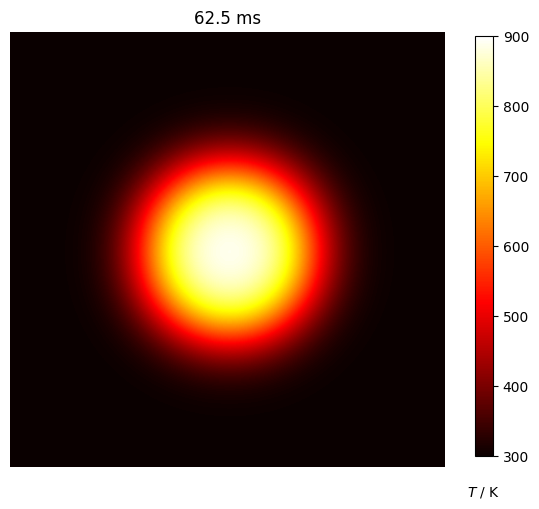

In [ ]:
# plate size, mm
w = h = 10.0
# intervals in x, y directions, mm
dx = dy = 0.1
# Thermal diffusivity of steel, mm2.s-1, D=1/alpha
D = 4.0 

Tcool, Thot = 300, 900 # in K

nx, ny = int(w/dx), int(h/dy)

dx2, dy2 = dx*dx, dy*dy
dt = dx2*dy2 / (2*D*(dx2 + dy2)) # maximun dt allowed (theory)
print('dt =',dt)

u0 = Tcool*np.ones((nx, ny)) # init grid (100x100) in 300K
u = u0.copy()

# Initial conditions: circle of radius r centred at (cx,cy) (mm) at thot
r, cx, cy = 2, 5, 5
r2 = r**2
for i in range(nx):
    for j in range(ny):
        p2 = (i*dx - cx)**2 + (j*dy - cy)**2
        if p2 < r2:
            u0[i, j] = Thot

# Number of times teps with dt=0.000625
nsteps = 101
# timesteps
fig, ax = plt.subplots(figsize=(6,6) )

start = tm.process_time() #Starting time counter for user
# propagate the signal
for m in range(nsteps):
    u = Diffusion2D(u0,nx,ny,dt,D)
    u0 = u.copy()
end = tm.process_time() # Finishing time counter for user
print('CPU time (s)=', end-start ) # Storing result

im = ax.imshow(u.copy(),cmap="hot",vmin=Tcool,vmax=Thot,interpolation="bilinear",)
ax.set_axis_off()
ax.set_title("{:.1f} ms".format(m*dt*1000))

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / K", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
print('\nfigure of 10x10, circle of radio 2 initial a 900 K. The system evolve 62.5 ms')
plt.show()

### **slicing rutine in c**
In NumPy, slicing is the process of extracting a subset of elements from an array. It follows the general syntax [start:stop:step], where start is inclusive and stop is exclusive

dt = 0.0006250000000000001
CPU time (s)= 0.0068202390000013935

figure of 10x10, circle of radio 2 initial a 900K. The system evolve 62.5 ms


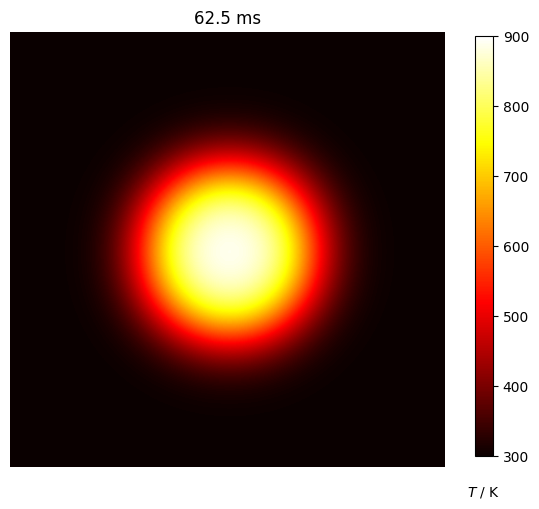

In [ ]:
# plate size, mm
w = h = 10.0
# intervals in x, y directions, mm
dx = dy = 0.1
# Thermal diffusivity of steel, mm2.s-1 D=1/alpha
D = 4.0 

Tcool, Thot = 300, 900

nx, ny = int(w/dx), int(h/dy)

dx2, dy2 = dx*dx, dy*dy
dt = dx2*dy2/(2*D*(dx2 + dy2)) #maximun t allowed
print('dt =',dt)

u0 = Tcool*np.ones((nx, ny)) #init grid (100x100) in 300K
u = u0.copy()

# Initial conditions: circle of radius r centred at (cx,cy) (mm)
r, cx, cy = 2, 5, 5
r2 = r**2
for i in range(nx):
    for j in range(ny):
        p2 = (i * dx - cx) ** 2 + (j * dy - cy) ** 2
        if p2 < r2:
            u0[i, j] = Thot

def do_timestep(u0, u):
    # Propagate with forward-difference in time, central-difference in space. Notice that dx=dy and the slicing
    u[1:-1, 1:-1] = u0[1:-1, 1:-1] + D*dt*(u0[2:, 1:-1] + u0[:-2, 1:-1] + u0[1:-1, 2:] + u0[1:-1, :-2]- 4*u0[1:-1, 1:-1])/dx2
s
    u0 = u.copy()
    return u0, u

# Number of times teps with dt=0.000625
nsteps = 101
# timesteps.
mfig = 50
fig, ax = plt.subplots(figsize=(6,6) )

start = tm.process_time() # Starting time counter for user
for m in range(nsteps): # propagate the signal
    u0, u = do_timestep(u0, u)
end = tm.process_time() # Finishing time counter for user
print('CPU time (s)=' ,end-start ) # Storing result

im = ax.imshow(u.copy(),cmap="hot",vmin=Tcool,vmax=Thot,interpolation="bilinear",)
ax.set_axis_off()
ax.set_title("{:.1f} ms".format(m*dt*1000))

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$ / K", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
print('\nfigure of 10x10, circle of radio 2 initial a 900K. The system evolve 62.5 ms')
plt.show()

This system analytical needs the Bessel funtions to do the Fourier series.

The state of the system is plotted as an image at four different stages of its evolution.

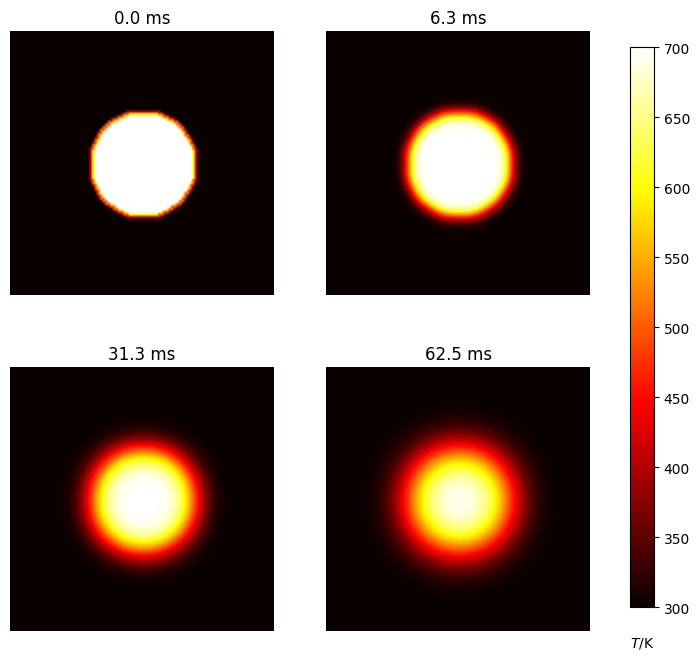

In [9]:
# plate size, mm
w = h = 10.0
# intervals in x, y directions, mm
dx = dy = 0.1
# Thermal diffusivity of steel, mm2.s-1, D=1/alpha
D = 4.0 

Tcool, Thot = 300, 700

nx, ny = int(w/dx), int(h/dy)

dx2, dy2 = dx*dx, dy*dy
dt = dx2*dy2/(2*D*(dx2 + dy2)) #maximun t allowed

u0 = Tcool * np.ones((nx, ny)) #init grid (100x100) in 300K
u = u0.copy()

# Initial conditions: circle of radius r centred at (cx,cy) (mm)
r, cx, cy = 2, 5, 5
r2 = r**2
for i in range(nx):
    for j in range(ny):
        p2 = (i*dx - cx)** 2 + (j*dy - cy)** 2
        if p2 < r2:
            u0[i, j] = Thot

def do_timestep(u0, u):
    # Propagate with forward-difference in time, central-difference in space. Notice that dx=dy
    u[1:-1, 1:-1] = u0[1:-1, 1:-1] + D*dt*(u0[2:, 1:-1] - 4 * u0[1:-1, 1:-1] + u0[:-2, 1:-1] + u0[1:-1, 2:] + u0[1:-1, :-2])/dx2

    u0 = u.copy()
    return u0, u

# Number of timesteps.
nsteps = 101
# Output 4 figures at these timesteps.
mfig = [0, 10, 50, 100]
fignum = 0
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,8) )
for m in range(nsteps):
    u0, u = do_timestep(u0, u)
    if m in mfig:
        #print(m, fignum)
        ax = axes[fignum // 2, fignum % 2]
        im = ax.imshow(
            u.copy(),
            cmap="hot",
            vmin=Tcool,
            vmax=Thot,
            interpolation="bilinear",
        )
        ax.set_axis_off()
        ax.set_title("{:.1f} ms".format(m*dt*1000))
        fignum += 1
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("$T$/K", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

- - -
#### Lab_4_FDM_diffusion:
